# 1: STAC & Cloud-Optimized GeoTIFF

Search a STAC catalog, sign asset URLs, then stream a COG window over HTTP


In [1]:
# STAC search, signed Planetary Computer URLs, and raster I/O
import pystac_client
import planetary_computer
import rasterio
from rasterio.windows import from_bounds       # pixel window from geographic bounds
from rasterio.warp import transform_bounds     # convert lon/lat → the raster CRS

## Open the catalog

Microsoft Planetary Computer STAC API (no API key required for read).

In [2]:
# Connect to a public STAC API. This returns metadata only — no imagery is downloaded.
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

## List collections

A STAC **collection** is a dataset family (for example Sentinel-2 L2A). The table below shows id, title, time range, and a few keywords.

In [3]:
import pandas as pd

# Build one table row per STAC collection (a dataset family, e.g. Sentinel-2 L2A)
rows = []
for col in catalog.get_collections():
    # Temporal extent is [start, end]; either side can be missing
    interval = None
    if col.extent and col.extent.temporal and col.extent.temporal.intervals:
        start, end = col.extent.temporal.intervals[0]
        start_txt = start.date().isoformat() if start else "…"
        end_txt = end.date().isoformat() if end else "present"
        interval = f"{start_txt} → {end_txt}"

    rows.append(
        {
            "id": col.id,
            "title": col.title or "",
            "time range": interval or "",
            "keywords": ", ".join((col.keywords or [])[:5]),
        }
    )

collections_df = pd.DataFrame(rows)
print(f"Total collections: {len(collections_df)}")

# Workshop collections first, then the rest A–Z
priority = ["sentinel-2-l2a", "landsat-c2-l2", "modis-09A1-061", "naip"]
collections_df["_rank"] = collections_df["id"].map(
    lambda i: priority.index(i) if i in priority else len(priority)
)
collections_df = collections_df.sort_values(["_rank", "id"]).drop(columns="_rank")

# Styled table (first 15 rows). Change .head(15) to see more.
collections_df.head(15).style.set_properties(**{"text-align": "left"}).hide(
    axis="index"
)

Total collections: 136


id,title,time range,keywords
sentinel-2-l2a,Sentinel-2 Level-2A,2015-06-27 → present,"Sentinel, Copernicus, ESA, Satellite, Global"
landsat-c2-l2,Landsat Collection 2 Level-2,1982-08-22 → present,"Landsat, USGS, NASA, Satellite, Global"
modis-09A1-061,MODIS Surface Reflectance 8-Day (500m),2000-02-18 → present,"NASA, MODIS, Satellite, Imagery, Global"
naip,NAIP: National Agriculture Imagery Program,2010-01-01 → 2023-12-31,"NAIP, Aerial, Imagery, USDA, AFPO"
3dep-lidar-classification,USGS 3DEP Lidar Classification,2012-01-01 → 2022-01-01,"USGS, 3DEP, COG, Classification"
3dep-lidar-copc,USGS 3DEP Lidar Point Cloud,2012-01-01 → 2022-01-01,"USGS, 3DEP, COG, Point cloud"
3dep-lidar-dsm,USGS 3DEP Lidar Digital Surface Model,2012-01-01 → 2022-01-01,"USGS, 3DEP, COG, DSM"
3dep-lidar-dtm,USGS 3DEP Lidar Digital Terrain Model,2012-01-01 → 2022-01-01,"USGS, 3DEP, COG, DTM"
3dep-lidar-dtm-native,USGS 3DEP Lidar Digital Terrain Model (Native),2012-01-01 → 2022-01-01,"USGS, 3DEP, COG, DTM"
3dep-lidar-hag,USGS 3DEP Lidar Height above Ground,2012-01-01 → 2022-01-01,"USGS, 3DEP, COG, Elevation"


## Search by bbox and datetime

Use Sentinel-2 L2A over **northern Karnataka, India**, for one month.
`bbox` is `[min_lon, min_lat, max_lon, max_lat]`.

In [4]:
# Bounding box: northern Karnataka, India
# Order is always [min_lon, min_lat, max_lon, max_lat]  (west, south, east, north)
BBOX = [75.62, 16.20, 77.29, 17.47]

search = catalog.search(
    collections=["sentinel-2-l2a"],          # analysis-ready Sentinel-2
    bbox=BBOX,
    datetime="2023-06-01/2023-06-30",        # inclusive date range
    max_items=10,                            # stop after 10 scenes
    query={"eo:cloud_cover": {"lt": 10}},    # less than 10% cloud
)
items = list(search.items())  # Item = one scene (one date + one tile)
print(f"Found {len(items)} items")

Found 10 items


## Inspect one item

Each item has `id`, `datetime`, `bbox`, `geometry`, and `assets` (dict of asset key → Asset with `href`).

In [5]:
# Inspect the first scene. An Item has place, time, and assets (file URLs).
item = items[0]
print("Item ID:", item.id)
print("Datetime:", item.datetime)
print("Bbox:", item.bbox)  # [min_lon, min_lat, max_lon, max_lat]
print("\nAssets:")  # B04 = red, B08 = NIR, visual = RGB preview, …
for key, asset in item.assets.items():
    print(f"  {key}: {asset.href[:80]}...")

Item ID: S2B_MSIL2A_20230620T051659_R062_T43QGV_20230620T114531
Datetime: 2023-06-20 05:16:59.024000+00:00
Bbox: [76.8791573, 17.075693, 77.9261272, 18.0798198]

Assets:
  AOT: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B01: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B02: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B03: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B04: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B05: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B06: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B07: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B08: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B...
  B09: http

## Sign items (Planetary Computer)

Signed URLs are required for access. Sign the item so asset `href`s can be used by rasterio/rioxarray.

Signed URL: A secure link that appends a Shared Access Signature (SAS) token to an Azure Blob Storage asset URL, granting temporary read access

In [6]:
# Planetary Computer blocks unsigned URLs (HTTP 403). Sign once, then reuse hrefs.
# Signed URLs expire after a few hours — re-run this cell if a later open fails.
signed_item = planetary_computer.sign(item)
url = signed_item.assets["B04"].href  # red band COG
print("Signed B04 href:", url[:90], "...")

Signed B04 href: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/43/Q/GV/2023/06/20/S2B_MSIL2A_20 ...


## Open the COG 

A Cloud-Optimized GeoTIFF is tiled so `rasterio.open(url)` can use HTTP range requests: metadata first, then only the tiles you read.

In [7]:
# Opening a COG URL reads the header only (CRS, size, tile layout) — not the pixels.
with rasterio.open(url) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Shape (height, width):", src.shape)
    print("Block size:", src.block_shapes)  # internal tile size (typical of a COG)

CRS: EPSG:32643
Bounds: BoundingBox(left=699960.0, bottom=1890240.0, right=809760.0, top=2000040.0)
Shape (height, width): (10980, 10980)
Block size: [(512, 512)]


## Read a window by geographic bounds

Request only a small subregion at the **center of the selected scene**; only those tiles are streamed.
Bounds are transformed from WGS84 into the raster CRS (UTM).

In [8]:
# Small window at the center of THIS scene (so the box always overlaps the tile)
minx, miny, maxx, maxy = signed_item.bbox  # lon/lat of the scene
cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
delta = 0.08  # ~0.08° on each side (~8–9 km)
left, bottom, right, top = cx - delta, cy - delta, cx + delta, cy + delta

with rasterio.open(url) as src:
    # Raster is in UTM; convert the lon/lat box into that CRS
    left_t, bottom_t, right_t, top_t = transform_bounds(
        "EPSG:4326", src.crs, left, bottom, right, top
    )
    # Pixel window that covers that box — only those tiles are streamed
    window = from_bounds(left_t, bottom_t, right_t, top_t, src.transform)
    data = src.read(1, window=window)  # band 1 of this single-band COG

print("Window shape:", data.shape)
print("Min / max:", int(data.min()), int(data.max()))

Window shape: (1793, 1721)
Min / max: 1122 6868


## Quick plot

Sentinel-2 L2A is stored as `uint16` (reflectance × 10000). Stretch with percentiles so the window is visible — a raw `imshow` often looks black.

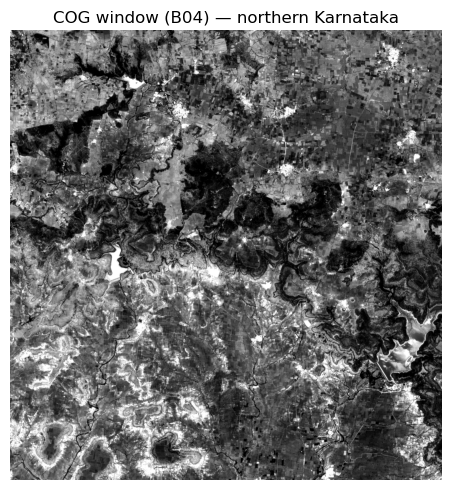

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# B04 is uint16 (reflectance × 10000). Stretch 2–98% so land is visible.
valid = data[data > 0]  # ignore nodata zeros
vmin, vmax = np.percentile(valid, (2, 98))

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.imshow(data, cmap="gray", vmin=vmin, vmax=vmax)
ax.set_title("COG window (B04) — northern Karnataka")
ax.axis("off")
plt.tight_layout()
plt.show()

## RGB preview

The `visual` asset is a 3-band RGB COG (B04, B03, B02 already stacked). The same geographic window is streamed — still not a full-scene download.

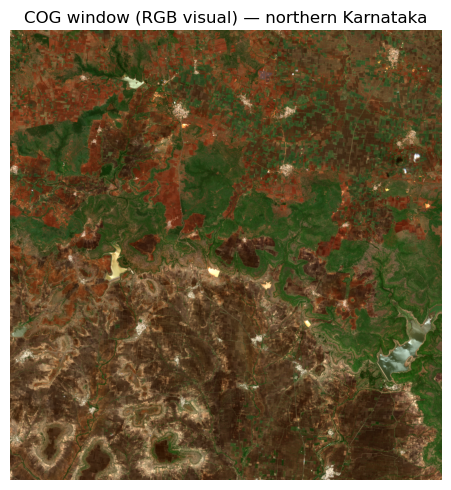

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# "visual" is a ready-made 3-band RGB COG (red, green, blue already stacked)
visual_url = signed_item.assets["visual"].href

with rasterio.open(visual_url) as src:
    # Same lon/lat window as the B04 read (left, bottom, right, top)
    left_t, bottom_t, right_t, top_t = transform_bounds(
        "EPSG:4326", src.crs, left, bottom, right, top
    )
    window = from_bounds(left_t, bottom_t, right_t, top_t, src.transform)
    rgb = src.read(window=window)  # shape (3, height, width)
    rgb_transform = src.window_transform(window)  # geotransform of this window
    rgb_profile = src.profile.copy()  # metadata used when writing a file later

# matplotlib wants (height, width, 3)
img = np.moveaxis(rgb, 0, -1)
if img.dtype != np.uint8:
    img = img.astype("float32")
    hi = np.percentile(img[img > 0], 98)
    img = np.clip(img / hi, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.imshow(img)
ax.set_title("COG window (RGB visual) — northern Karnataka")
ax.axis("off")
plt.tight_layout()
plt.show()

## Download the RGB window

Write only the AOI window to a local tiled GeoTIFF (a small COG), not the full scene.

In [11]:
from pathlib import Path

# Write only the AOI window (not the full scene) as a tiled GeoTIFF
out_path = Path("output/s2_rgb_aoi.tif")
out_path.parent.mkdir(parents=True, exist_ok=True)

# Update size and geotransform to match the window we read
rgb_profile.update(
    height=rgb.shape[1],
    width=rgb.shape[2],
    count=rgb.shape[0],          # 3 RGB bands
    transform=rgb_transform,
    compress="deflate",
    tiled=True,                  # tiled layout ≈ Cloud-Optimized GeoTIFF
    blockxsize=256,
    blockysize=256,
)

with rasterio.open(out_path, "w", **rgb_profile) as dst:
    dst.write(rgb)

print("Wrote", out_path.resolve())
print("Size:", out_path.stat().st_size, "bytes")
print("Shape:", rgb.shape)

Wrote /Users/amanchaudhary/Desktop/scalable-raster-analytics-course/notebooks/output/s2_rgb_aoi.tif
Size: 7829531 bytes
Shape: (3, 1793, 1721)
